# Лаб. 4 — генерация лиц (VAE)

CelebA: безусловная генерация → условная по полу (CVAE). Метрики FID и IS.

## Настройки

In [ ]:
%matplotlib inline

from pathlib import Path
import csv
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import save_image
from tqdm.auto import tqdm

from torchvision.models import inception_v3, Inception_V3_Weights

BASE = Path(".").resolve()
RAW_DIR = BASE / "dataset" / "raw"
FACES_DIR = BASE / "dataset" / "faces"
ATTR_FILE_TXT = RAW_DIR / "list_attr_celeba.txt"
ATTR_FILE_CSV = RAW_DIR / "list_attr_celeba.csv"
ATTR_FILE = ATTR_FILE_TXT if ATTR_FILE_TXT.exists() else ATTR_FILE_CSV
CKPT_DIR = BASE / "workspace" / "checkpoints"
SAMPLE_DIR = BASE / "workspace" / "samples"
METRICS_DIR = BASE / "workspace" / "metrics"
LOG_DIR = BASE / "workspace" / "logs"
for d in (FACES_DIR, CKPT_DIR, SAMPLE_DIR, METRICS_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = 1612
IMG_SIZE = 64
LATENT_DIM = 128
BATCH_SIZE = 16
EPOCHS_VAE = 30
EPOCHS_CVAE = 30
LR = 2e-4
MAX_IMAGES = 30000
NUM_WORKERS = 0  # Windows/Jupyter: если зависнет — 0 или 2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = DEVICE == "cuda"
IMG_EXT = {".jpg", ".jpeg", ".png"}

random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

## Подготовка лиц

CelebA aligned → resize `IMG_SIZE`×`IMG_SIZE` в `dataset/faces/`. Если размер изменился — ячейка пересоберёт faces из raw.

лиц в faces/: 30000 | целевой размер: 64


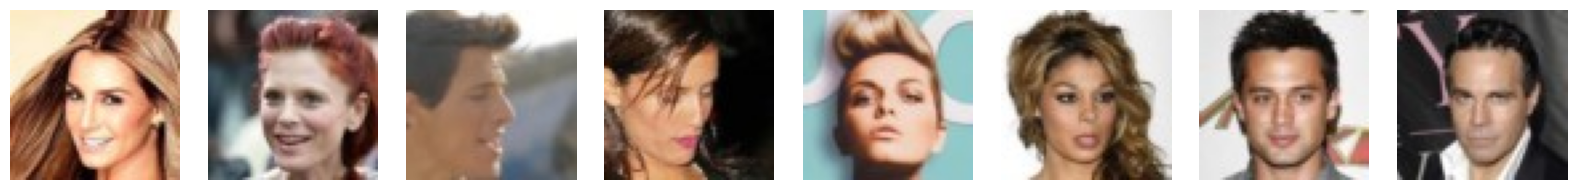

In [2]:
ALIGN_DIR = RAW_DIR / "img_align_celeba" / "img_align_celeba"
if not ALIGN_DIR.exists():
    ALIGN_DIR = RAW_DIR / "img_align_celeba"

SIZE_MARKER = FACES_DIR / ".img_size"
existing = sorted(p for p in FACES_DIR.iterdir() if p.suffix.lower() in IMG_EXT)
print("лиц в faces/:", len(existing), "| целевой размер:", IMG_SIZE)

need_prep = ALIGN_DIR.exists() and (
    len(existing) < 1000
    or not SIZE_MARKER.exists()
    or SIZE_MARKER.read_text(encoding="utf-8").strip() != str(IMG_SIZE)
)

if need_prep:
    src = sorted(p for p in ALIGN_DIR.rglob("*") if p.suffix.lower() in IMG_EXT)
    if MAX_IMAGES:
        src = src[:MAX_IMAGES]
    tf = transforms.Compose([transforms.Resize(IMG_SIZE), transforms.CenterCrop(IMG_SIZE)])
    for p in tqdm(src, desc=f"faces {IMG_SIZE}"):
        tf(Image.open(p).convert("RGB")).save(FACES_DIR / p.name, quality=90)
    SIZE_MARKER.write_text(str(IMG_SIZE), encoding="utf-8")
    existing = sorted(FACES_DIR.glob("*.jpg"))
elif len(existing) < 100:
    print("мало лиц — см. dataset/README.md")

face_paths = existing
n_show = min(8, len(face_paths))
if n_show:
    fig, ax = plt.subplots(1, n_show, figsize=(2 * n_show, 2))
    ax = np.atleast_1d(ax).ravel()
    for i, p in enumerate(face_paths[:n_show]):
        ax[i].imshow(Image.open(p))
        ax[i].axis("off")
    plt.tight_layout()
    display(fig)
    plt.close(fig)


## Атрибут пола

Колонка `Male` в `list_attr_celeba.txt` (или `list_attr_celeba.csv`), (+1 мужчина, -1 женщина).

In [3]:
def load_gender_map(attr_path, files):
    if not attr_path.exists():
        return {}

    wanted = {p.name for p in files}
    mp = {}

    if attr_path.suffix.lower() == ".csv":
        with attr_path.open("r", encoding="utf-8", newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                img_name = row.get("image_id")
                if not img_name or img_name not in wanted:
                    continue
                mp[img_name] = 1 if int(float(row["Male"])) == 1 else 0
    else:
        lines = attr_path.read_text(encoding="utf-8").strip().splitlines()
        names = lines[0].split()
        male_idx = names.index("Male")
        for line in lines[1:]:
            parts = line.split()
            mp[parts[0]] = 1 if int(parts[1 + male_idx]) == 1 else 0

    return {p.name: mp[p.name] for p in files if p.name in mp}

gender_map = load_gender_map(ATTR_FILE, face_paths)
if gender_map:
    nm = sum(v == 1 for v in gender_map.values())
    print("с меткой:", len(gender_map), "| male:", nm, "| female:", len(gender_map) - nm)


с меткой: 30000 | male: 12680 | female: 17320


## Архитектура VAE

Свёрточный encoder/decoder; число слоёв зависит от `IMG_SIZE`

In [10]:
import math


def _n_downsample(img_size, min_spatial=4):
    n = int(round(math.log2(img_size / min_spatial)))
    if 2 ** n * min_spatial != img_size:
        raise ValueError(f"IMG_SIZE={img_size}: нужна степень двойки (64, 128, 256, ...)")
    return n


def _channels(n_down):
    base = [32, 64, 128, 256]
    return [base[min(i, len(base) - 1)] for i in range(n_down)]


class Encoder(nn.Module):
    def __init__(self, img_size=64, latent_dim=128):
        super().__init__()
        n_down = _n_downsample(img_size)
        chs = _channels(n_down)
        layers = []
        in_ch = 3
        for out_ch in chs:
            layers.extend([nn.Conv2d(in_ch, out_ch, 4, 2, 1), nn.ReLU()])
            in_ch = out_ch
        self.net = nn.Sequential(*layers)
        with torch.no_grad():
            h = self.net(torch.zeros(1, 3, img_size, img_size))
            self.flat_dim = h.view(1, -1).size(1)
            self.enc_out_ch = h.size(1)
        self.mu = nn.Linear(self.flat_dim, latent_dim)
        self.logvar = nn.Linear(self.flat_dim, latent_dim)

    def forward(self, x):
        h = self.net(x).flatten(1)
        return self.mu(h), self.logvar(h)


class Decoder(nn.Module):
    def __init__(self, in_dim=128, img_size=64):
        super().__init__()
        n_down = _n_downsample(img_size)
        chs = _channels(n_down)
        self.enc_out_ch = chs[-1]
        self.fc = nn.Linear(in_dim, self.enc_out_ch * 4 * 4)
        layers = []
        in_ch = self.enc_out_ch
        for out_ch in reversed(chs[:-1]):
            layers.extend([nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1), nn.ReLU()])
            in_ch = out_ch
        layers.extend([nn.ConvTranspose2d(in_ch, 3, 4, 2, 1), nn.Sigmoid()])
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(self.fc(z).view(-1, self.enc_out_ch, 4, 4))


class VAE(nn.Module):
    def __init__(self, latent_dim=128, img_size=64):
        super().__init__()
        self.enc = Encoder(img_size, latent_dim)
        self.dec = Decoder(latent_dim, img_size)

    def reparam(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(logvar)

    def forward(self, x):
        mu, logvar = self.enc(x)
        return self.dec(self.reparam(mu, logvar)), mu, logvar


def vae_loss(x, recon, mu, logvar):
    recon_l = F.mse_loss(recon, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_l + kl, recon_l.item(), kl.item()


## Обучение VAE

`RUN_TRAIN_VAE = True` — учить заново; `False` — взять `workspace/checkpoints/vae.pt`.

In [5]:
class FaceDataset(Dataset):
    def __init__(self, paths, labels=None):
        self.paths = paths
        self.labels = labels
        self.tf = transforms.Compose([
            transforms.Resize(IMG_SIZE),
            transforms.CenterCrop(IMG_SIZE),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        x = self.tf(Image.open(self.paths[idx]).convert("RGB"))
        if self.labels is None:
            return x
        return x, self.labels[idx]


def train_epochs(model, loader, epochs, tag="vae"):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    hist = []
    for ep in range(1, epochs + 1):
        model.train()
        tot, rc, kl = 0.0, 0.0, 0.0
        for batch in loader:
            if isinstance(batch, (list, tuple)):
                x, y = batch[0].to(DEVICE), batch[1].to(DEVICE)
                opt.zero_grad(set_to_none=True)
                recon, mu, logvar = model(x, y)
            else:
                x = batch.to(DEVICE)
                opt.zero_grad(set_to_none=True)
                recon, mu, logvar = model(x)
            loss, r, k = vae_loss(x, recon, mu, logvar)
            loss.backward()
            opt.step()
            tot += loss.item()
            rc += r
            kl += k
        n = len(loader)
        row = {"epoch": ep, "loss": tot / n, "recon": rc / n, "kl": kl / n}
        hist.append(row)
        print(f"{tag} {ep}/{epochs} loss={row['loss']:.1f}")
    return hist


RUN_TRAIN_VAE = True
vae_ckpt = CKPT_DIR / "vae.pt"
paths = face_paths[:MAX_IMAGES] if MAX_IMAGES else face_paths
loader = DataLoader(
    FaceDataset(paths),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
)

vae = VAE(LATENT_DIM, img_size=IMG_SIZE)
if RUN_TRAIN_VAE or not vae_ckpt.exists():
    hist_vae = train_epochs(vae, loader, EPOCHS_VAE, "vae")
    torch.save(vae.state_dict(), vae_ckpt)
    (LOG_DIR / "vae_loss.json").write_text(json.dumps(hist_vae, indent=2), encoding="utf-8")
else:
    vae.load_state_dict(torch.load(vae_ckpt, map_location=DEVICE, weights_only=True))
    hist_vae = json.loads((LOG_DIR / "vae_loss.json").read_text(encoding="utf-8"))
    print("загружен", vae_ckpt)


vae 1/30 loss=369.4
vae 2/30 loss=238.7
vae 3/30 loss=215.6
vae 4/30 loss=205.7
vae 5/30 loss=200.5
vae 6/30 loss=196.8
vae 7/30 loss=194.0
vae 8/30 loss=192.1
vae 9/30 loss=190.3
vae 10/30 loss=188.9
vae 11/30 loss=187.7
vae 12/30 loss=186.7
vae 13/30 loss=185.7
vae 14/30 loss=185.0
vae 15/30 loss=184.2
vae 16/30 loss=183.5
vae 17/30 loss=183.0
vae 18/30 loss=182.3
vae 19/30 loss=181.9
vae 20/30 loss=181.2
vae 21/30 loss=180.9
vae 22/30 loss=180.3
vae 23/30 loss=179.9
vae 24/30 loss=179.4
vae 25/30 loss=179.0
vae 26/30 loss=178.6
vae 27/30 loss=178.2
vae 28/30 loss=177.9
vae 29/30 loss=177.5
vae 30/30 loss=177.2


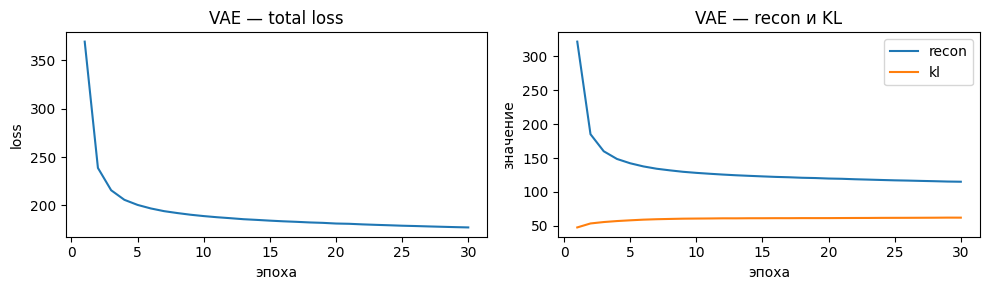

VAE — безусловные сэмплы (случайный z → decoder):


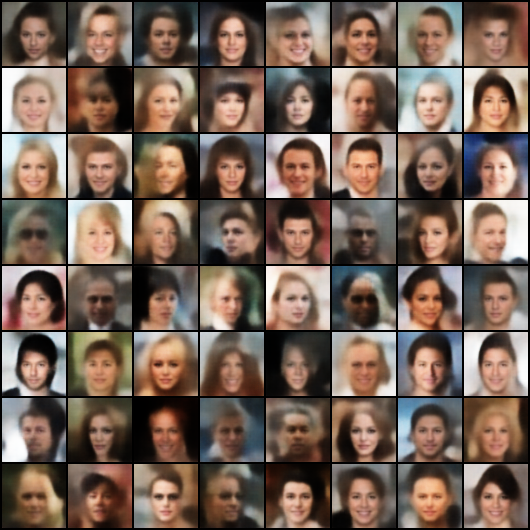

In [6]:
if hist_vae:
    ep = [r["epoch"] for r in hist_vae]
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(ep, [r["loss"] for r in hist_vae])
    ax[0].set_title("VAE — total loss")
    ax[0].set_xlabel("эпоха")
    ax[0].set_ylabel("loss")
    ax[1].plot(ep, [r["recon"] for r in hist_vae], label="recon")
    ax[1].plot(ep, [r["kl"] for r in hist_vae], label="kl")
    ax[1].set_title("VAE — recon и KL")
    ax[1].set_xlabel("эпоха")
    ax[1].set_ylabel("значение")
    ax[1].legend()
    plt.tight_layout()
    display(fig)
    plt.close(fig)

vae.eval()
with torch.no_grad():
    samp = vae.dec(torch.randn(64, LATENT_DIM, device=DEVICE)).cpu()
p = SAMPLE_DIR / "vae_uncond.png"
save_image(samp, p, nrow=8)
print("VAE — безусловные сэмплы (случайный z → decoder):")
display(Image.open(p))


## CVAE — условие по полу

One-hot пола добавляется к latent перед decoder.

In [7]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=128, n_classes=2, img_size=64):
        super().__init__()
        self.n_classes = n_classes
        self.enc = Encoder(img_size, latent_dim)
        self.dec = Decoder(latent_dim + n_classes, img_size)

    def forward(self, x, y):
        mu, logvar = self.enc(x)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(logvar)
        yh = F.one_hot(y, self.n_classes).float()
        return self.dec(torch.cat([z, yh], dim=1)), mu, logvar


RUN_TRAIN_CVAE = True
cvae_ckpt = CKPT_DIR / "cvae.pt"
cvae = None
hist_cvae = []

lp = [p for p in paths if p.name in gender_map]
lb = [gender_map[p.name] for p in lp]
cvae_loader = DataLoader(
	FaceDataset(lp, lb),
	batch_size=BATCH_SIZE,
	shuffle=True,
	num_workers=NUM_WORKERS,
	pin_memory=PIN_MEMORY,
	drop_last=True,
)
cvae = CVAE(LATENT_DIM, img_size=IMG_SIZE)
if RUN_TRAIN_CVAE or not cvae_ckpt.exists():
	hist_cvae = train_epochs(cvae, cvae_loader, EPOCHS_CVAE, "cvae")
	torch.save(cvae.state_dict(), cvae_ckpt)
	(LOG_DIR / "cvae_loss.json").write_text(json.dumps(hist_cvae, indent=2), encoding="utf-8")
else:
	cvae.load_state_dict(torch.load(cvae_ckpt, map_location=DEVICE, weights_only=True))
	hist_cvae = json.loads((LOG_DIR / "cvae_loss.json").read_text(encoding="utf-8"))
	print("загружен", cvae_ckpt)


cvae 1/30 loss=370.9
cvae 2/30 loss=236.1
cvae 3/30 loss=214.2
cvae 4/30 loss=204.7
cvae 5/30 loss=199.2
cvae 6/30 loss=195.6
cvae 7/30 loss=193.1
cvae 8/30 loss=190.9
cvae 9/30 loss=189.4
cvae 10/30 loss=188.0
cvae 11/30 loss=186.8
cvae 12/30 loss=185.9
cvae 13/30 loss=184.9
cvae 14/30 loss=184.2
cvae 15/30 loss=183.4
cvae 16/30 loss=182.9
cvae 17/30 loss=182.2
cvae 18/30 loss=181.7
cvae 19/30 loss=181.1
cvae 20/30 loss=180.6
cvae 21/30 loss=180.2
cvae 22/30 loss=179.7
cvae 23/30 loss=179.4
cvae 24/30 loss=179.1
cvae 25/30 loss=178.8
cvae 26/30 loss=178.4
cvae 27/30 loss=178.2
cvae 28/30 loss=177.7
cvae 29/30 loss=177.5
cvae 30/30 loss=177.1


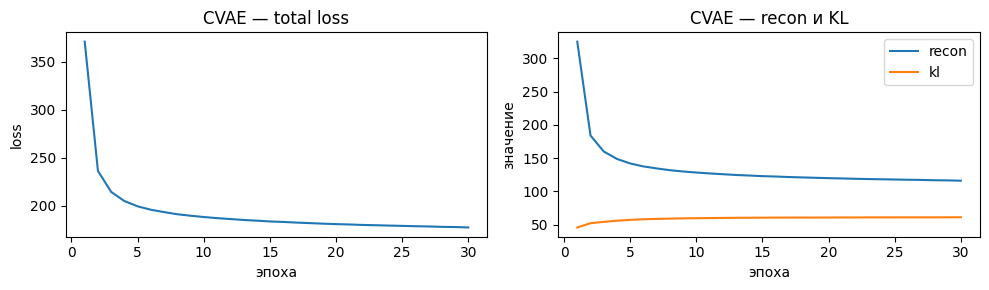

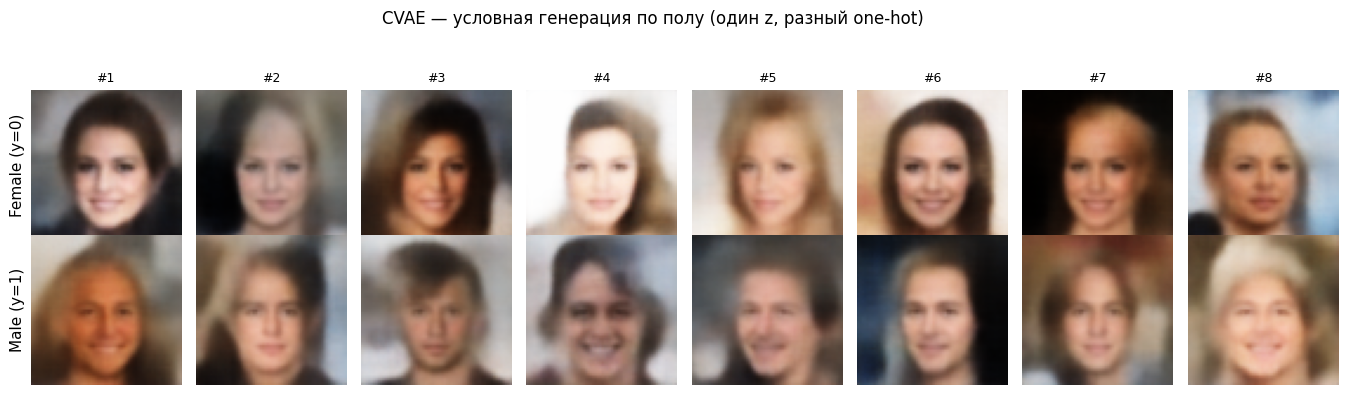

In [8]:
if hist_cvae:
    ep = [r["epoch"] for r in hist_cvae]
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(ep, [r["loss"] for r in hist_cvae])
    ax[0].set_title("CVAE — total loss")
    ax[0].set_xlabel("эпоха")
    ax[0].set_ylabel("loss")
    ax[1].plot(ep, [r["recon"] for r in hist_cvae], label="recon")
    ax[1].plot(ep, [r["kl"] for r in hist_cvae], label="kl")
    ax[1].set_title("CVAE — recon и KL")
    ax[1].set_xlabel("эпоха")
    ax[1].set_ylabel("значение")
    ax[1].legend()
    plt.tight_layout()
    display(fig)
    plt.close(fig)

if cvae is not None:
    cvae.eval()
    fig, ax = plt.subplots(2, 8, figsize=(14, 4))
    row_labels = {0: "Female (y=0)", 1: "Male (y=1)"}
    for row, y_val in enumerate([0, 1]):
        y = torch.full((8,), y_val, dtype=torch.long, device=DEVICE)
        z = torch.randn(8, LATENT_DIM, device=DEVICE)
        with torch.no_grad():
            yh = F.one_hot(y, 2).float()
            imgs = cvae.dec(torch.cat([z, yh], dim=1)).cpu()
        for c in range(8):
            ax[row, c].imshow(imgs[c].permute(1, 2, 0).numpy())
            ax[row, c].set_xticks([])
            ax[row, c].set_yticks([])
            for spine in ax[row, c].spines.values():
                spine.set_visible(False)
            if row == 0:
                ax[row, c].set_title(f"#{c + 1}", fontsize=9)
        ax[row, 0].set_ylabel(row_labels[y_val], fontsize=11)
    fig.suptitle("CVAE — условная генерация по полу (один z, разный one-hot)", fontsize=12)
    plt.tight_layout(rect=[0.03, 0, 1, 0.92])
    out = SAMPLE_DIR / "cvae_gender.png"
    plt.savefig(out, dpi=120, bbox_inches="tight")
    display(fig)
    plt.close(fig)


## FID и IS

Inception v3 (torchvision). Сравнение 1024 реальных и 1024 сгенерированных.

In [9]:
def _sqrtm_psd(mat):
    """Квадратный корень PSD-матрицы (NumPy 2.x убрал sqrtm из numpy.linalg)."""
    mat = (mat + mat.T) / 2
    vals, vecs = np.linalg.eigh(mat)
    vals = np.clip(vals, 0, None)
    return vecs @ (np.sqrt(vals)[:, None] * vecs.T)


def inception_feats(batch_01, model):
    x = F.interpolate(batch_01.to(DEVICE), (299, 299), mode="bilinear", align_corners=False)
    x = (x - 0.5) * 2
    with torch.no_grad():
        return model(x).cpu().numpy()


def calc_fid(real_f, fake_f):
    mu1, mu2 = real_f.mean(0), fake_f.mean(0)
    s1, s2 = np.cov(real_f, rowvar=False), np.cov(fake_f, rowvar=False)
    diff = mu1 - mu2
    covmean = _sqrtm_psd(s1 @ s2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(s1 + s2 - 2 * covmean))


def calc_is(images_01, clf, splits=5):
    bs = 32
    probs = []
    for i in range(0, len(images_01), bs):
        x = F.interpolate(images_01[i : i + bs].to(DEVICE), (299, 299), mode="bilinear", align_corners=False)
        x = (x - 0.5) * 2
        with torch.no_grad():
            probs.append(F.softmax(clf(x), dim=1).cpu().numpy())
    p = np.concatenate(probs, 0)
    scores = []
    n = p.shape[0]
    chunk = max(1, n // splits)
    for i in range(splits):
        part = p[i * chunk : (i + 1) * chunk]
        py = part.mean(0)
        kl = part * (np.log(part + 1e-8) - np.log(py + 1e-8))
        scores.append(np.exp(kl.sum(1).mean()))
    return float(np.mean(scores)), float(np.std(scores))


n_eval = 1024
real_t = torch.stack([loader.dataset[i] for i in range(min(n_eval, len(loader.dataset)))])
vae.eval()
with torch.no_grad():
    fake_t = vae.dec(torch.randn(n_eval, LATENT_DIM, device=DEVICE)).cpu()

inc_emb = inception_v3(weights=Inception_V3_Weights.DEFAULT, transform_input=False)
inc_emb.fc = nn.Identity()
inc_emb.eval().to(DEVICE)
inc_cls = inception_v3(weights=Inception_V3_Weights.DEFAULT).eval().to(DEVICE)

fr, ff = inception_feats(real_t, inc_emb), inception_feats(fake_t, inc_emb)
fid_val = calc_fid(fr, ff)
is_m, is_s = calc_is(fake_t, inc_cls)
metrics = {"fid": fid_val, "is_mean": is_m, "is_std": is_s, "n_eval": n_eval}
print("Метрики VAE (1024 real vs 1024 fake):")
print(f"  FID = {fid_val:.2f}  (меньше — лучше)")
print(f"  IS  = {is_m:.2f} ± {is_s:.2f}  (больше — лучше)")
(METRICS_DIR / "fid_is.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

# --- CVAE: условные метрики по полу ---
if "cvae" not in globals() or cvae is None:
    print("CVAE не обучен (cvae is None) — пропускаю FID/IS для CVAE")
else:
    # Полагаемся на gender_map и paths из предыдущих ячеек.
    male_paths = [p for p in paths if (p.name in gender_map and gender_map[p.name] == 1)]
    female_paths = [p for p in paths if (p.name in gender_map and gender_map[p.name] == 0)]

    n_eval_each = 512  # male + female = 1024

    male_ds = FaceDataset(male_paths)
    female_ds = FaceDataset(female_paths)

    n_m = min(n_eval_each, len(male_ds))
    n_f = min(n_eval_each, len(female_ds))

    if n_m < 10 or n_f < 10:
        print("Мало размеченных лиц для CVAE FID/IS:", "male=", n_m, "female=", n_f)
    else:
        real_m = torch.stack([male_ds[i] for i in range(n_m)])
        real_f = torch.stack([female_ds[i] for i in range(n_f)])

        cvae.eval()
        with torch.no_grad():
            z_m = torch.randn(n_m, LATENT_DIM, device=DEVICE)
            y_m = torch.ones(n_m, dtype=torch.long, device=DEVICE)  # y=1 male
            yh_m = F.one_hot(y_m, 2).float()
            fake_m = cvae.dec(torch.cat([z_m, yh_m], dim=1)).cpu()

            z_f = torch.randn(n_f, LATENT_DIM, device=DEVICE)
            y_f = torch.zeros(n_f, dtype=torch.long, device=DEVICE)  # y=0 female
            yh_f = F.one_hot(y_f, 2).float()
            fake_f = cvae.dec(torch.cat([z_f, yh_f], dim=1)).cpu()

        inc_emb = inc_emb  # reuse
        inc_cls = inc_cls  # reuse

        fr_m, ff_m = inception_feats(real_m, inc_emb), inception_feats(fake_m, inc_emb)
        fr_f, ff_f = inception_feats(real_f, inc_emb), inception_feats(fake_f, inc_emb)

        fid_m = calc_fid(fr_m, ff_m)
        fid_f = calc_fid(fr_f, ff_f)
        fid_avg = 0.5 * (fid_m + fid_f)

        is_m_mean, is_m_std = calc_is(fake_m, inc_cls)
        is_f_mean, is_f_std = calc_is(fake_f, inc_cls)
        is_avg_mean = 0.5 * (is_m_mean + is_f_mean)

        metrics_cvae = {
            "fid_male": fid_m,
            "fid_female": fid_f,
            "fid_avg": fid_avg,
            "is_male_mean": is_m_mean,
            "is_male_std": is_m_std,
            "is_female_mean": is_f_mean,
            "is_female_std": is_f_std,
            "is_avg_mean": is_avg_mean,
            "n_male": n_m,
            "n_female": n_f,
        }

        print("Метрики CVAE (условные, по полу):")
        print(f"  FID(male) = {fid_m:.2f} | FID(female) = {fid_f:.2f} | FID(avg) = {fid_avg:.2f}")
        print(f"  IS(male) = {is_m_mean:.2f} ± {is_m_std:.2f}")
        print(f"  IS(female) = {is_f_mean:.2f} ± {is_f_std:.2f}")

        (METRICS_DIR / "fid_is_cvae.json").write_text(json.dumps(metrics_cvae, indent=2), encoding="utf-8")


Метрики VAE (1024 real vs 1024 fake):
  FID = 102.56  (меньше — лучше)
  IS  = 1.69 ± 0.02  (больше — лучше)
Метрики CVAE (условные, по полу):
  FID(male) = 125.87 | FID(female) = 102.14 | FID(avg) = 114.00
  IS(male) = 1.64 ± 0.03
  IS(female) = 1.63 ± 0.05


## Вывод

**Данные:** 30k лиц CelebA, **64×64**, атрибут пола из `list_attr_celeba.csv`.

**VAE (30 эпох):** recon 322 → 115, KL 48 → 62 — обучение сошлось, latent не «занулился». Сэмплы узнаваемые, но размытые (MSE + классический VAE).

**CVAE:** условие one-hot по полу в decoder меняет черты, но при **одном `z` на столбец** мужские лица часто мягкие — слабый сигнал пола и размытость VAE; для демонстрации пола логичнее независимые `z` в рядах.

**Метрики VAE** (1024 real vs 1024 fake):
- **FID = 102.6** — fake всё ещё далеки от real, но оценка стабильнее при `n_eval=1024`.
- **IS = 1.69 ± 0.02** — низко, картинки однотипные для Inception.

**Метрики CVAE** (512 male + 512 female, условная генерация):
- **FID:** male **125.9**, female **102.1**, avg **114.0** — в среднем чуть хуже VAE; male-ветка заметно слабее.
- **IS:** male **1.64 ± 0.03**, female **1.63 ± 0.05** — почти как у VAE.

Метрики согласуются с `cvae_gender.png`: пол влияет слабо, мужские сэмплы мягкие; female по FID почти на уровне VAE.

**Улучшения (смотрел, не внедрял):** β-VAE, KL annealing, perceptual loss.

Задание: лица, VAE, CVAE по полу, кривые loss, FID + IS (VAE и CVAE) — выполнено.